# Results Overview — Fed Policy ML Project

All results shown below are generated automatically by the project pipeline.

This notebook does not perform any model training.
It provides a clean visual summary of the main results produced by the pipeline (`python main.py`).

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

PROJECT_ROOT = Path("..")
RESULTS_DIR = PROJECT_ROOT / "results"


## Model comparison (out-of-sample performance)

Models are evaluated on the 2016–2025 test period.
Lower RMSE indicates better predictive performance.

In [2]:
df_results = pd.read_csv(RESULTS_DIR / "model_comparison.csv")
df_results
df_results.round(3)

,model,rmse_train,mae_train,r2_train,rmse_test,mae_test,r2_test
0,TaylorRule_OLS,0.372,0.353,0.946,0.408,0.288,0.936
1,RandomForest,0.240,0.186,0.978,1.412,1.100,0.238
2,Lasso,0.241,0.179,0.977,1.433,1.266,0.216
3,XGBoost,0.001,0.001,1.000,1.473,1.200,0.171
4,Ridge,0.238,0.181,0.978,2.058,1.928,-0.619


## Best-performing model

The Taylor-rule-style OLS benchmark achieves the lowest test RMSE, highlighting the strong
performance of simple and economically grounded models in a small-sample, time-series setting.

Overall, simple econometric benchmarks outperform machine-learning models in this context,
emphasizing the importance of economic structure over model complexity.

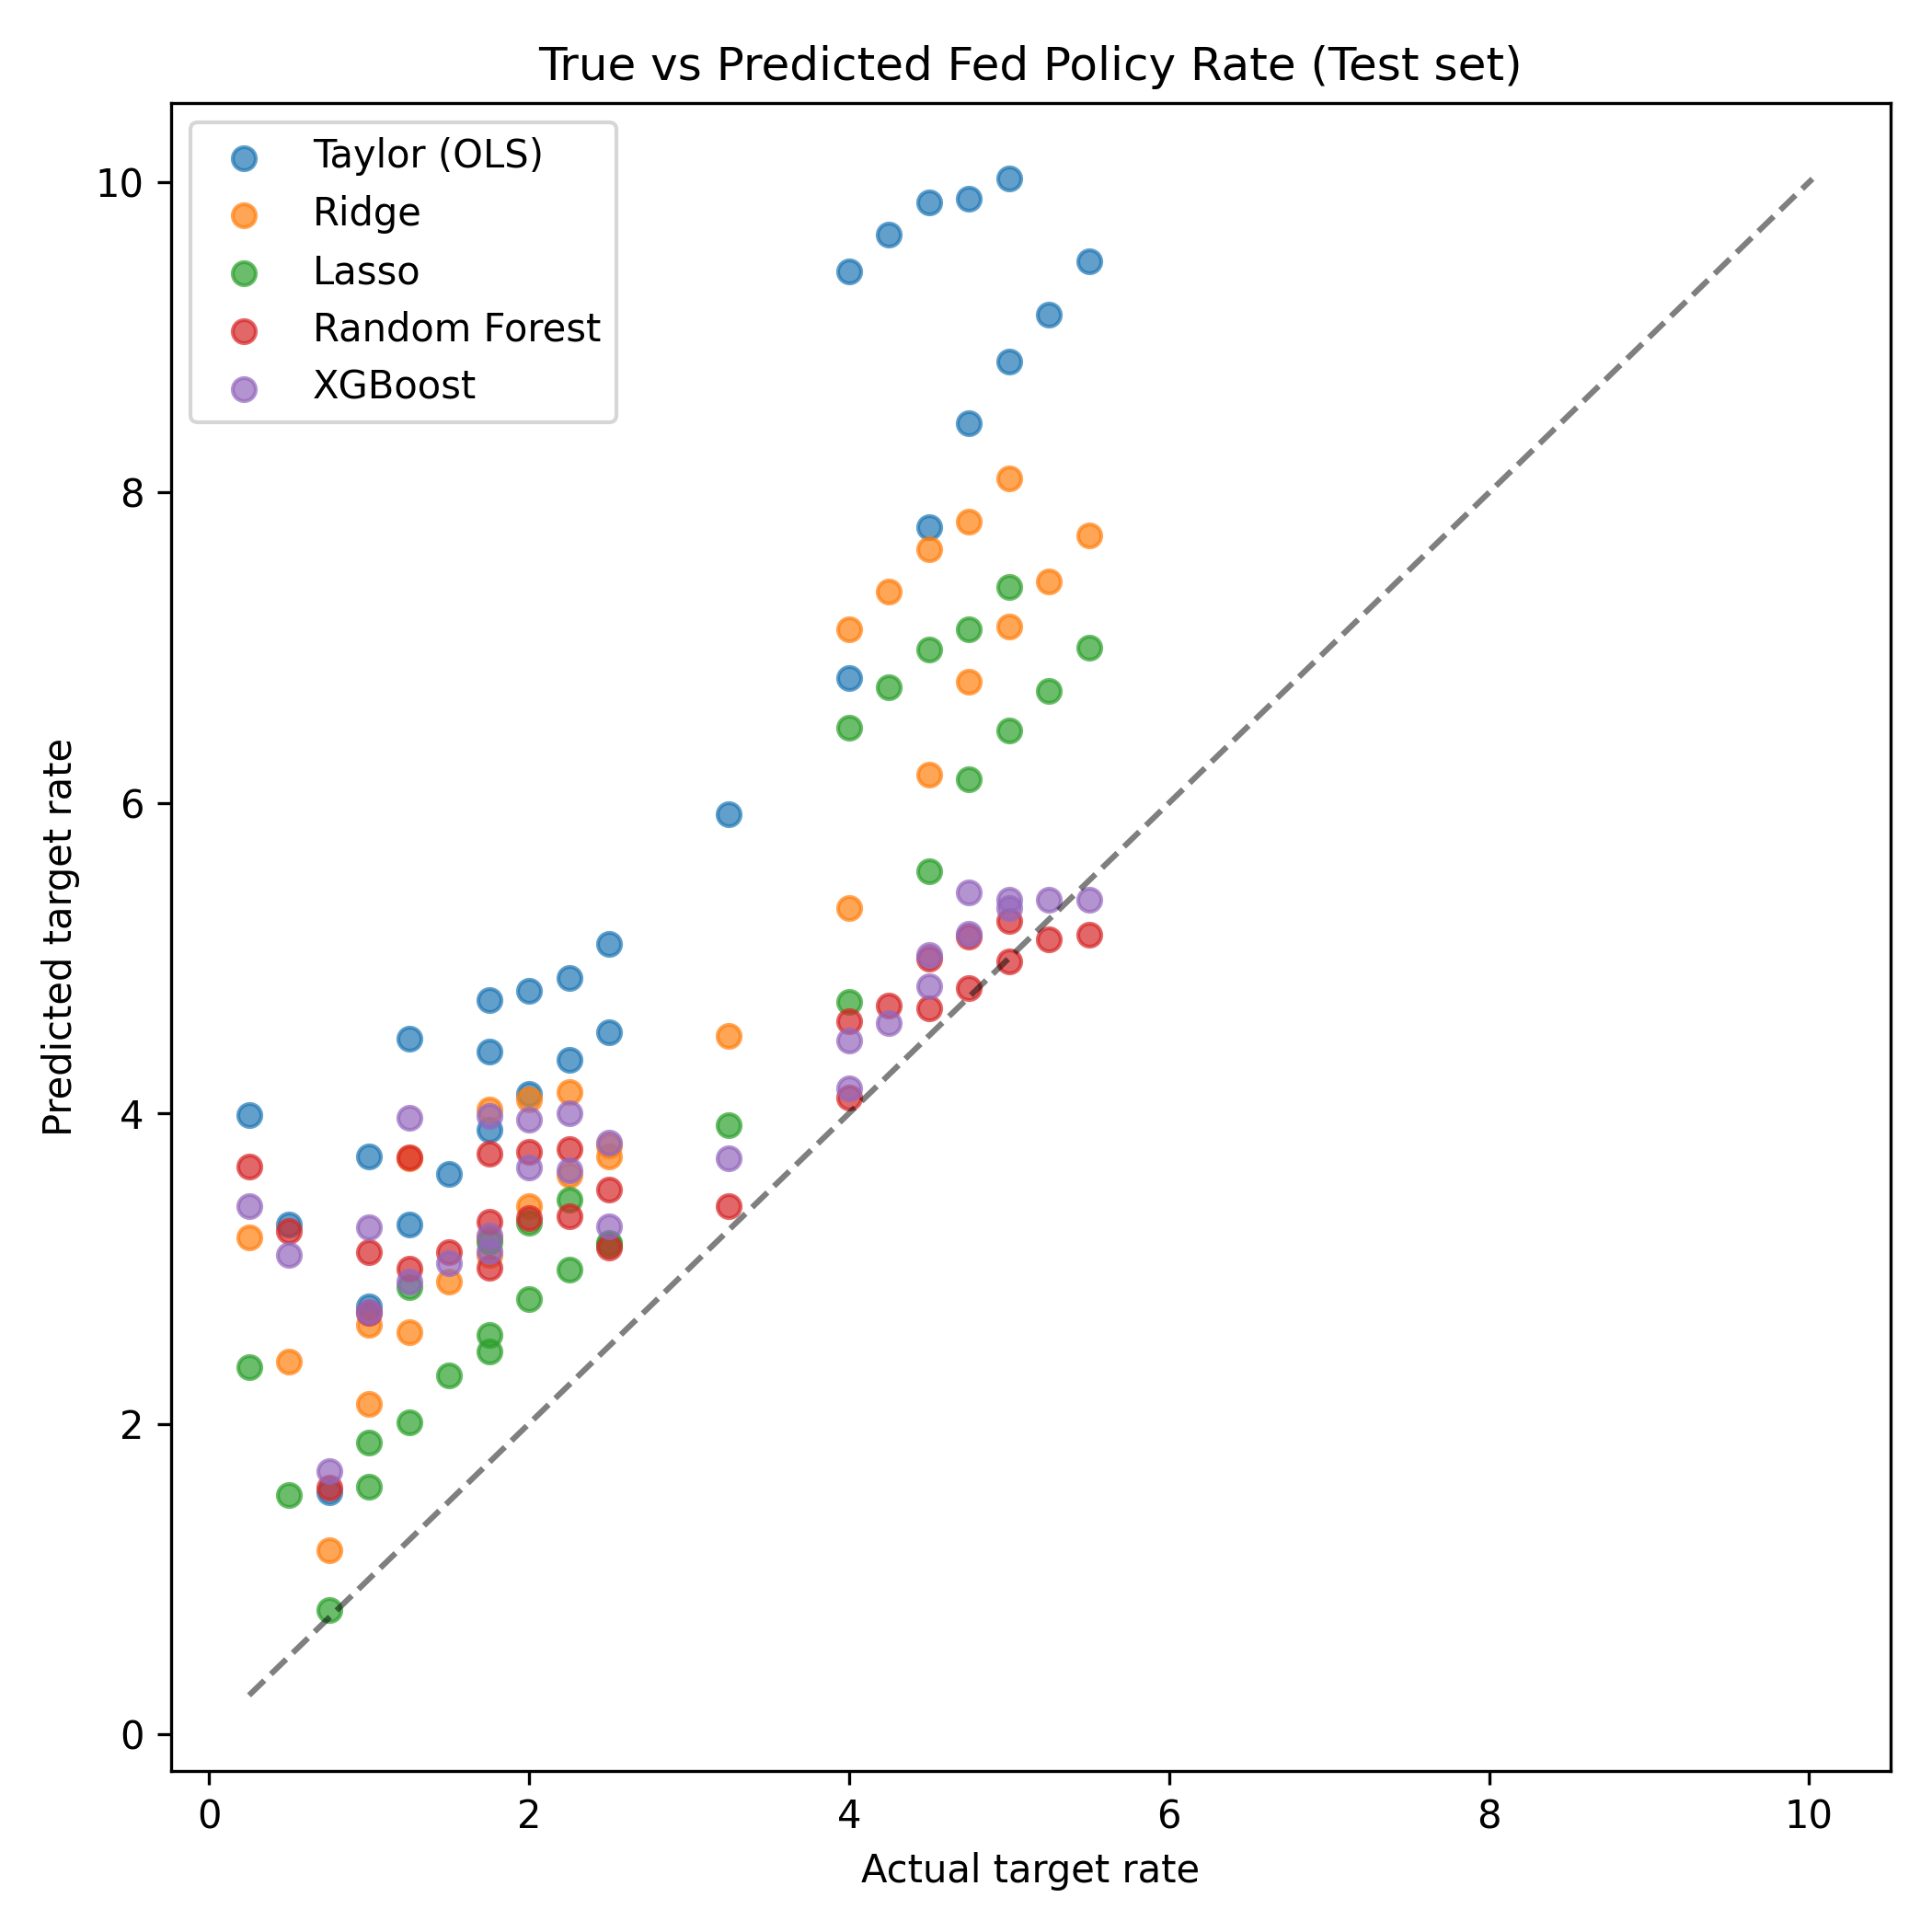

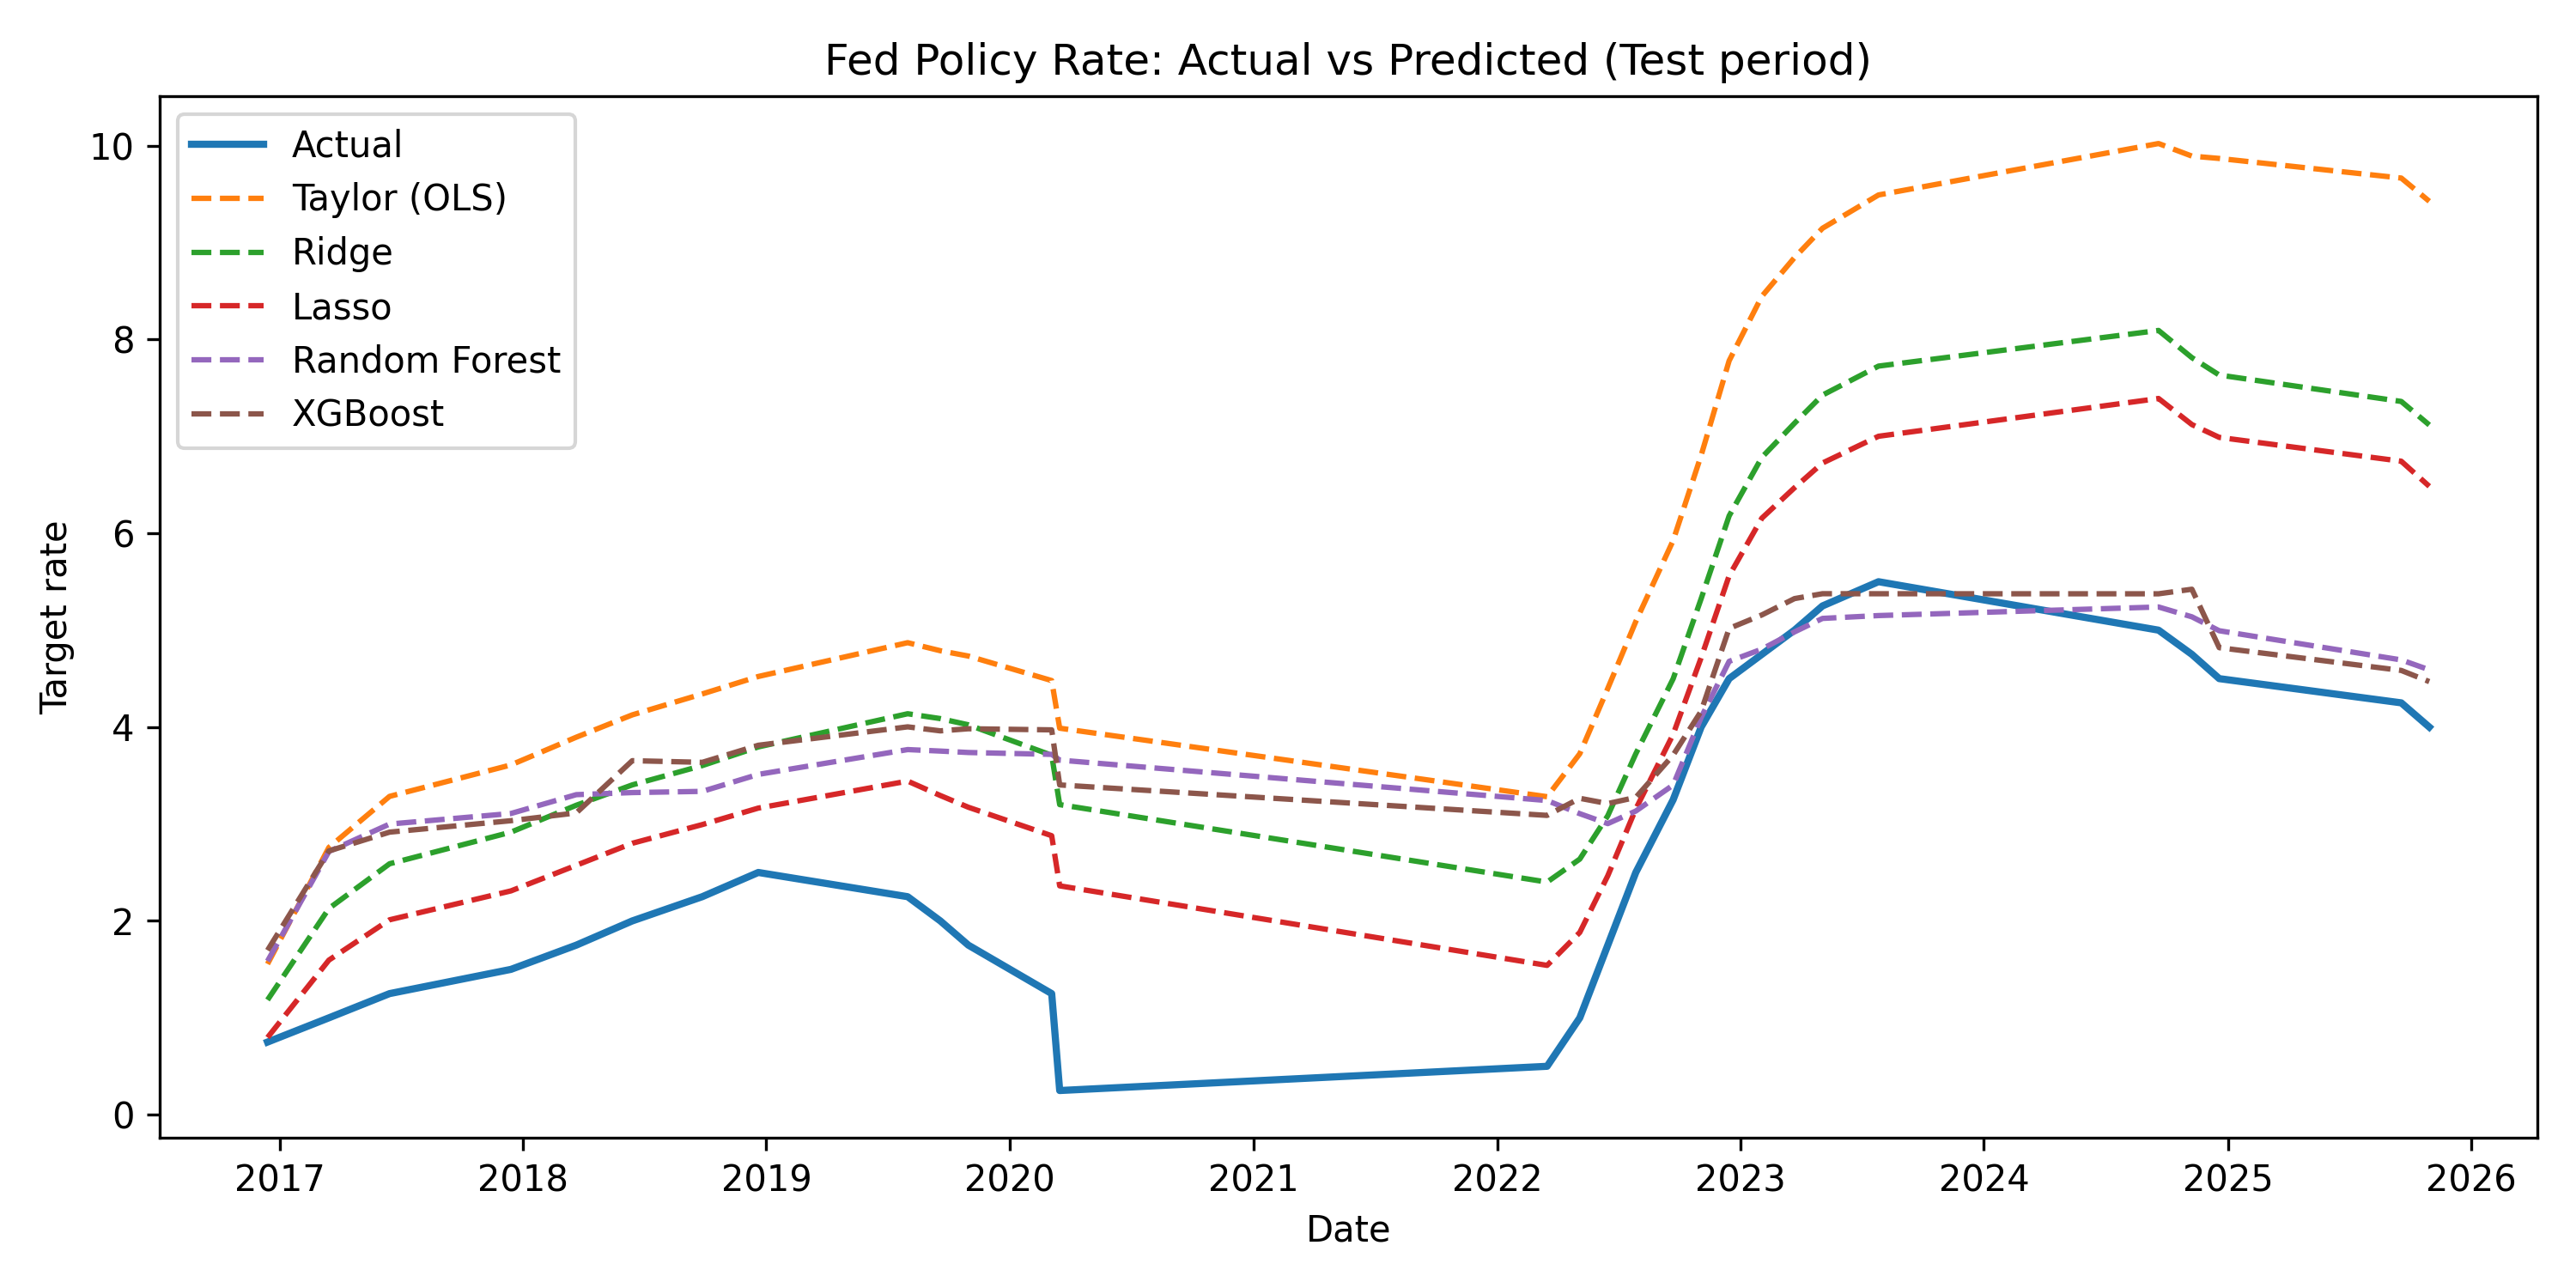

In [3]:
fig1 = RESULTS_DIR / "true_vs_predicted.png"
fig2 = RESULTS_DIR / "time_series_predictions.png"

display(Image(filename=str(fig1)))
display(Image(filename=str(fig2)))

In [4]:
import pandas as pd
from pathlib import Path

# The notebook is located in the /notebooks directory.
# We therefore define the project root as the parent directory.
PROJECT_ROOT = Path("..")
RESULTS_DIR = PROJECT_ROOT / "results"

# Load the model comparison results generated by the main pipeline
df = pd.read_csv(RESULTS_DIR / "model_comparison.csv")

# Keep only out-of-sample performance metrics for reporting
# (training metrics are not reported in the paper)
df = df[["model", "rmse_test", "mae_test", "r2_test"]]

# Rename columns for clarity and LaTeX compatibility
df = df.rename(columns={
    "model": "Model",
    "rmse_test": "RMSE",
    "mae_test": "MAE",
    "r2_test": r"$R^2$"
})

# Improve readability of model names in the final table
df["Model"] = df["Model"].str.replace("_", " ", regex=False)

# Export the table in LaTeX format with a fixed number of decimals
# to ensure consistent and professional presentation in the report
out_path = RESULTS_DIR / "model_comparison.tex"
df.to_latex(
    out_path,
    index=False,
    escape=False,
    float_format="%.3f"
)

print(f"LaTeX table successfully saved to: {out_path.resolve()}")

LaTeX table successfully saved to: /files/Project-DSAP/results/model_comparison.tex
